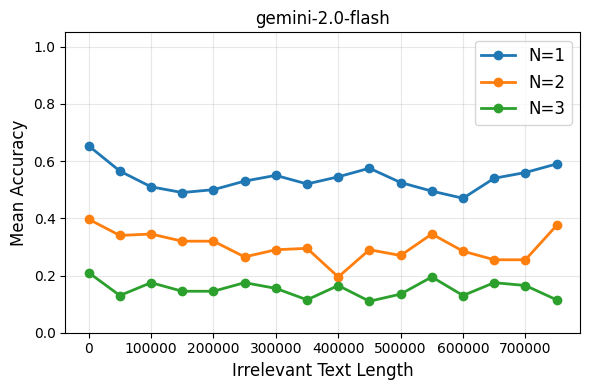

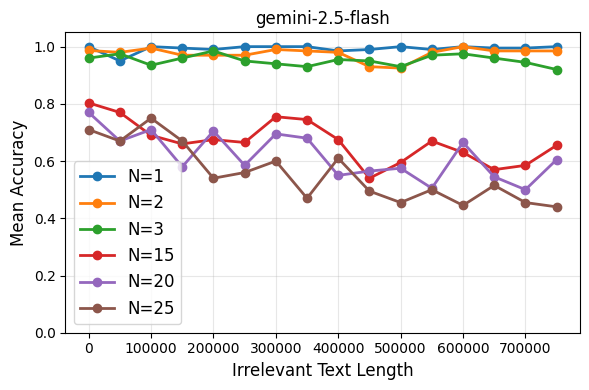

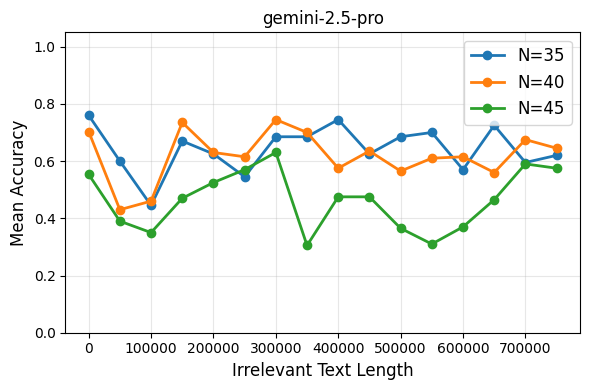

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

model_config = {
    "gemini-2.0-flash": [1, 2, 3],
    "gemini-2.5-flash": [1, 2, 3, 15, 20, 25],
    "gemini-2.5-pro": [35, 40, 45],
}

record_file = 'records'

for model_name, N_values_to_plot in model_config.items():
    # Load CSV file
    csv_path = f'/Users/hwanda/Desktop/EdenCode/projects/PyCliffordMCP/dev/pauli_string_multiplication/direct_multiplication/{record_file}/{model_name}/accuracy_summary.csv'
    
    try:
        df = pd.read_csv(csv_path)
        
        # Filter to temperature=0.0 only
        df = df[df['temperature'] == 0.0]
        
        # Create plot
        plt.figure(figsize=(6, 4))
        
        # Plot only the specified N values
        for N in N_values_to_plot:
            # Filter data for this N value
            n_data = df[df['N'] == N]
            
            if len(n_data) > 0:  # Only plot if data exists
                # Group by L_irr and calculate mean accuracy
                grouped = n_data.groupby('L_irr')['accuracy'].mean()
                
                # Plot
                plt.plot(grouped.index, grouped.values, marker='o', label=f'N={N}', linewidth=2)
            else:
                print(f"Warning: No data found for N={N} in {model_name}")
        
        plt.xlabel('Irrelevant Text Length', fontsize=12)
        plt.ylabel('Mean Accuracy', fontsize=12)
        plt.title(f'{model_name}', fontsize=12)
        plt.legend(fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.ylim(0, 1.05)
        plt.tight_layout()
        plt.show()
        
    except FileNotFoundError:
        print(f"❌ File not found: {csv_path}")
    except Exception as e:
        print(f"❌ Error loading {model_name}: {e}")

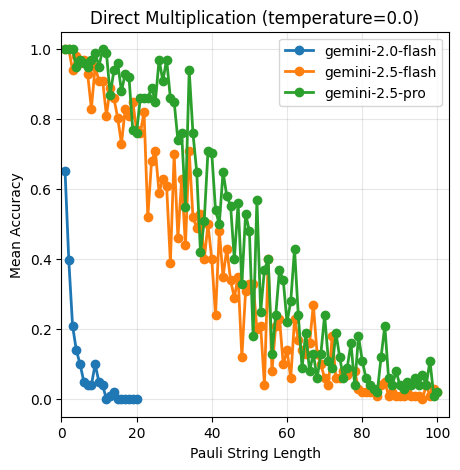

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Models to compare
models = ["gemini-2.0-flash", "gemini-2.5-flash", "gemini-2.5-pro"]
SHOW_ERROR_BARS = False  # Set to False to hide error bars

record_file = 'records'

plt.figure(figsize=(5, 5))

for model in models:
    # Load data
    csv_path = f'/Users/hwanda/Desktop/EdenCode/projects/PyCliffordMCP/dev/pauli_string_multiplication/direct_multiplication/{record_file}/{model}/accuracy_summary.csv'
    df = pd.read_csv(csv_path)
    
    # Filter to temperature=0.0 and L_irr=0 only
    df_clean = df[(df['temperature'] == 0.0) & (df['L_irr'] == 0)]
    grouped = df_clean.groupby('N')['accuracy'].agg(['mean', 'std'])
    
    # Plot with or without error bars
    if SHOW_ERROR_BARS:
        plt.errorbar(grouped.index, grouped['mean'], yerr=grouped['std'], 
                    marker='o', label=model, linewidth=2, capsize=5)
    else:
        plt.plot(grouped.index, grouped['mean'], marker='o', label=model, linewidth=2)

plt.xlabel('Pauli String Length')
plt.ylabel('Mean Accuracy')
plt.title('Direct Multiplication (temperature=0.0)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 103)
plt.ylim(-0.05, 1.05)
plt.show()

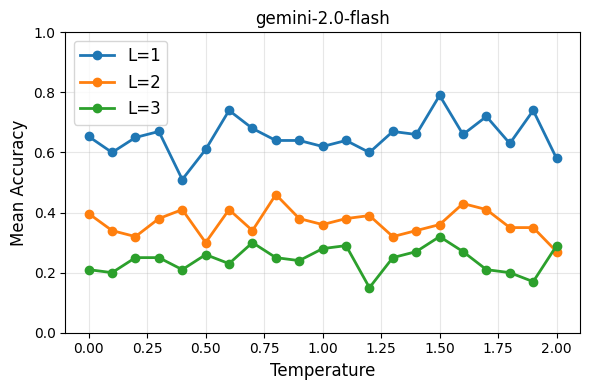

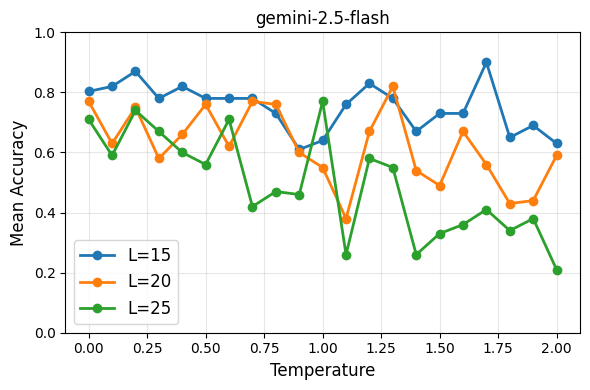

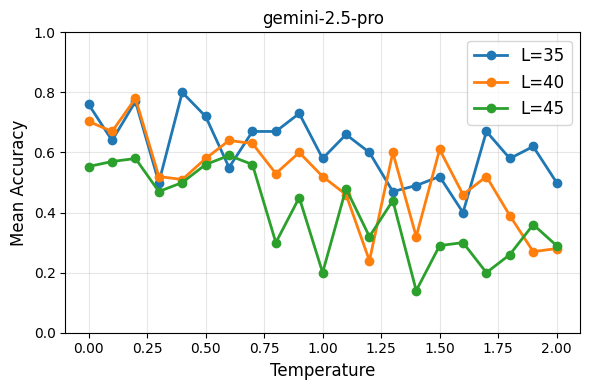

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

model_config = {
    "gemini-2.0-flash": [1,2,3],
    "gemini-2.5-flash": [15, 20, 25],
    "gemini-2.5-pro": [35, 40, 45],
}

record_file = 'records'

for model_name, N_values_to_plot in model_config.items():
    # Load CSV file
    csv_path = f'/Users/hwanda/Desktop/EdenCode/projects/PyCliffordMCP/dev/pauli_string_multiplication/direct_multiplication/{record_file}/{model_name}/accuracy_summary.csv'
    
    try:
        df = pd.read_csv(csv_path)
        
        df = df[df['L_irr'] == 0]
        
        # Create plot
        plt.figure(figsize=(6, 4))
        
        # Plot only the specified N values
        for N in N_values_to_plot:
            # Filter data for this N value
            n_data = df[df['N'] == N]
            
            if len(n_data) > 0:  # Only plot if data exists
                # Group by temperature and calculate mean accuracy
                grouped = n_data.groupby('temperature')['accuracy'].mean()
                
                # Plot
                plt.plot(grouped.index, grouped.values, marker='o', label=f'L={N}', linewidth=2)
            else:
                print(f"Warning: No data found for L={N} in {model_name}")
        
        plt.xlabel('Temperature', fontsize=12)
        plt.ylabel('Mean Accuracy', fontsize=12)
        plt.title(f'{model_name}', fontsize=12)
        plt.legend(fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.ylim(0, 1.0)
        plt.tight_layout()
        plt.show()
        
    except FileNotFoundError:
        print(f"❌ File not found: {csv_path}")
    except Exception as e:
        print(f"❌ Error loading {model_name}: {e}")